In [1]:
# 訓練データとテストデータの画像を読み込む
# （サイズは縦横224pxにリサイズする）
import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [2]:
# データの詳細を表示する
list(train_dataset.as_numpy_iterator())[0]

(array([[[[ 37.      ,  55.      ,  69.      ],
          [ 37.037945,  55.035713,  69.06696 ],
          [ 42.72991 ,  60.392857,  79.11161 ],
          ...,
          [ 74.30359 ,  61.966537,  50.97769 ],
          [ 76.98218 ,  64.97995 ,  52.986633],
          [ 77.      ,  65.      ,  53.      ]],
 
         [[ 37.049107,  55.04018 ,  69.06696 ],
          [ 37.087093,  55.07596 ,  69.13397 ],
          [ 42.785038,  60.442814,  79.18535 ],
          ...,
          [ 74.42643 ,  62.055897,  51.03357 ],
          [ 77.0983  ,  65.062584,  53.035786],
          [ 77.11607 ,  65.08259 ,  53.049107]],
 
         [[ 44.41518 ,  61.066963,  79.11161 ],
          [ 44.459145,  61.11246 ,  79.18534 ],
          [ 51.053932,  67.93669 ,  90.24567 ],
          ...,
          [ 92.85281 ,  75.45996 ,  59.41531 ],
          [ 94.515724,  77.45769 ,  60.40857 ],
          [ 94.52679 ,  77.470985,  60.41518 ]],
 
         ...,
 
         [[228.96654 , 210.96654 , 172.31474 ],
          [228.982

In [4]:
# 分類名（cat／dog）をリストとして格納する
class_names = train_dataset.class_names
class_names

['cat', 'dog']

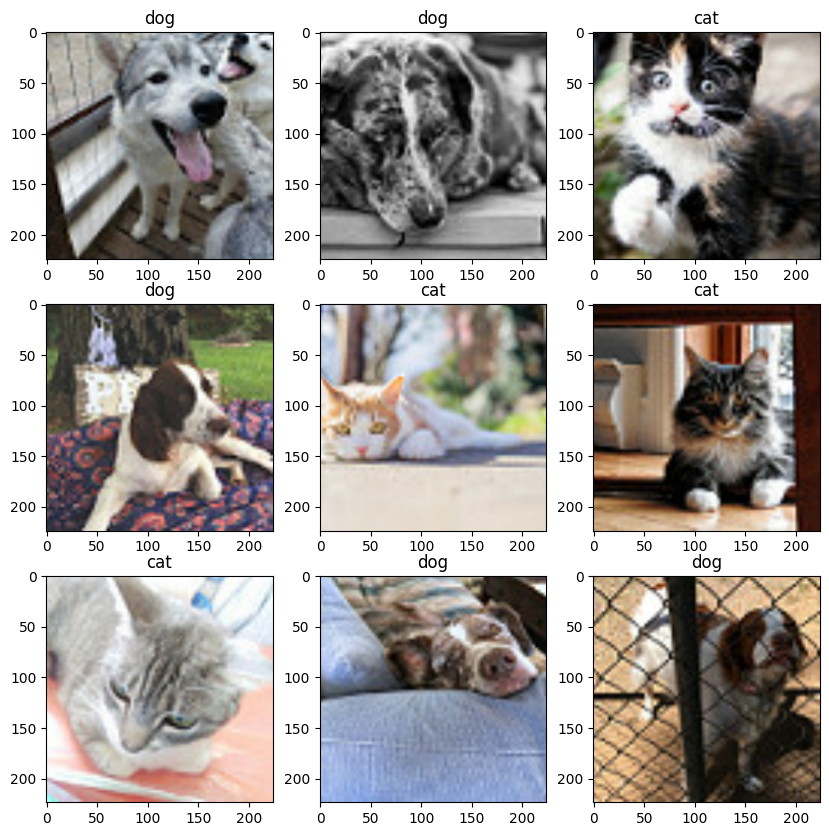

In [5]:
# 訓練データの一部を表示して確認
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [7]:
# 画像の水増しをする関数の定義
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

In [8]:
# 画像の水増し処理の実行
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [9]:
# 水増ししたデータを訓練データに追加する
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [10]:
# データをシャッフルする
train_dataset = train_dataset.shuffle(32)

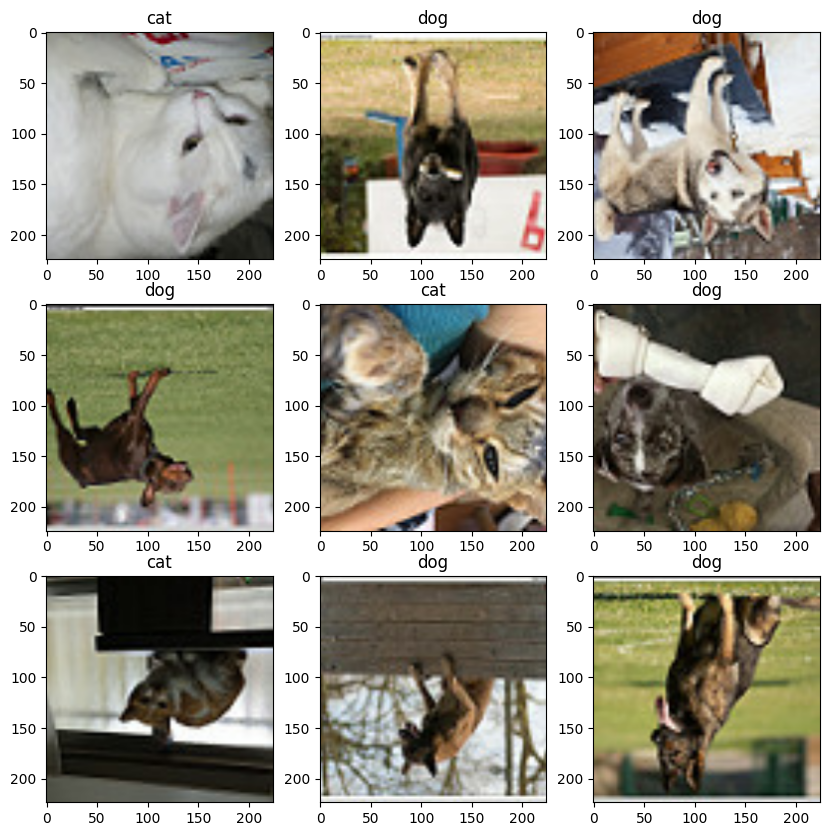

In [11]:
# 訓練データの一部を表示して確認
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [12]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [13]:
# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

In [14]:
# base_modelに先ほどのDense層を追加したモデルを作成する
model = tf.keras.Sequential([
    base_model,
    output_layer
])

In [15]:
# modelをcompileする
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

In [16]:
# modelに学習させる
model.fit(train_dataset, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 190ms/step - accuracy: 0.7711 - loss: 0.4949
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 201ms/step - accuracy: 0.9180 - loss: 0.2258
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 222ms/step - accuracy: 0.9525 - loss: 0.1551
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 238ms/step - accuracy: 0.9578 - loss: 0.1358
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.9669 - loss: 0.1158
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step - accuracy: 0.9721 - loss: 0.1037
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 208ms/step - accuracy: 0.9769 - loss: 0.0875
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 212ms/step - accuracy: 0.9786 - loss: 0.0793
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - accuracy: 0.9853 - loss: 0.0669
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 208ms/step - accuracy: 0.9891 - loss: 0.0600
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 208ms/step - accuracy: 0.9888 - loss: 0.0601
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 13

In [17]:
# テストデータで分類を実行する
pred_data = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 413ms/step


In [18]:
# 分類した結果を確認する
pred_data

array([[4.12915942e-05],
       [2.32853723e-04],
       [7.37529190e-05],
       [1.57936383e-03],
       [9.78307566e-04],
       [2.09926118e-04],
       [7.86639052e-04],
       [7.13896763e-04],
       [1.46160437e-05],
       [2.59905763e-04],
       [4.24459395e-05],
       [2.25515687e-03],
       [2.14939611e-03],
       [7.90900085e-04],
       [7.28802552e-05],
       [5.36923881e-06],
       [1.17333482e-04],
       [4.21131437e-04],
       [4.59530950e-03],
       [2.76188715e-03],
       [6.58060610e-03],
       [1.28557295e-01],
       [3.18506500e-03],
       [8.75517260e-04],
       [2.74408996e-01],
       [1.07740762e-03],
       [5.18161687e-04],
       [4.04972030e-04],
       [6.26792386e-03],
       [1.50175547e-04],
       [5.96762286e-04],
       [7.49465048e-01],
       [2.36660984e-04],
       [8.86828755e-04],
       [6.29889686e-03],
       [8.62078667e-01],
       [3.00773280e-03],
       [1.21061888e-03],
       [2.38029659e-02],
       [5.42599009e-04],


In [19]:
# evaluate()でモデルの性能を評価する
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.9600 - loss: 0.0661


[0.063322052359581, 0.9599999785423279]